# Student Academic Performance Prediction Using KNN

**Course:** BMCS2203 Artificial Intelligence  
**Algorithm:** K-Nearest Neighbors (KNN)  
**Student Name:** Lim Jun Hao  
**Student ID:** 26WMR12877

This notebook develops a supervised multiclass classification model that predicts student performance as **Low**, **Medium**, or **High**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## 1. Dataset preparation

The dataset is inspected for its size, missing values, and duplicated records. `Exam_Score` is then converted into the target classes below.

| Exam score | Performance class |
|---|---|
| 64 or below | Low |
| 65 to 69 | Medium |
| 70 or above | High |

Dataset shape: (6607, 20)
Duplicated rows: 0

Missing values:
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

Performance class distribution:
Performance
Low       1452
Medium    3530
High      1625
Name: count, dtype: int64


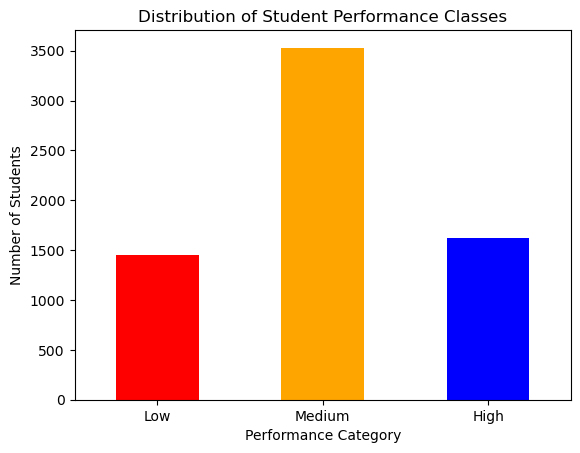

In [2]:
df = pd.read_csv("StudentPerformanceFactors.csv")

print("Dataset shape:", df.shape)
print("Duplicated rows:", df.duplicated().sum())
print()
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

df["Performance"] = pd.cut(
    df["Exam_Score"],
    bins=[-np.inf, 64, 69, np.inf],
    labels=["Low", "Medium", "High"],
    ordered=True
)

class_order = ["Low", "Medium", "High"]
class_counts = df["Performance"].value_counts().reindex(class_order)

print()
print("Performance class distribution:")
print(class_counts)

class_counts.plot(kind="bar", color=["red", "orange", "blue"])
plt.title("Distribution of Student Performance Classes")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()

## 2. Feature and target separation

`X` contains the student factors and `y` contains the target class. `Exam_Score` is removed from `X` because it was used to create `Performance`; keeping it would cause target leakage.

The data is split into 80% training and 20% testing data. Stratification maintains similar class proportions in both sets.

In [3]:
X = df.drop(columns=["Exam_Score", "Performance"])
y = df["Performance"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Numeric input features:", numeric_features)
print("Categorical input features:", categorical_features)
print()
print("Training class proportions:")
print(y_train.value_counts(normalize=True).sort_index())
print()
print("Testing class proportions:")
print(y_test.value_counts(normalize=True).sort_index())

Training data shape: (5285, 19)
Testing data shape: (1322, 19)
Numeric input features: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']
Categorical input features: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

Training class proportions:
Performance
Low       0.219678
Medium    0.534342
High      0.245979
Name: proportion, dtype: float64

Testing class proportions:
Performance
Low       0.220121
Medium    0.534039
High      0.245840
Name: proportion, dtype: float64


## 3. Preprocessing, feature selection, and KNN pipeline

Numerical features use median imputation and standardization. Categorical features use most-frequent imputation and one-hot encoding. `SelectKBest` retains the transformed features that have the strongest relationship with the target.

```text
Raw data -> preprocessing -> SelectKBest -> KNN
```

Every step is inside the Pipeline, so preprocessing and feature selection are fitted only on training data during cross-validation.

In [4]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(score_func=f_classif)),
    ("knn", KNeighborsClassifier(algorithm="ball_tree"))
])

parameter_grid = {
    "selector__k": [4, 6, 8, 10, 12, 15, 20, "all"],
    "knn__n_neighbors": [9, 15, 21, 31, 41, 51],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2]
}

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=parameter_grid,
    scoring={"accuracy": "accuracy", "macro_f1": "f1_macro"},
    refit="accuracy",
    cv=cross_validation,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Parameter combinations:", 8 * 6 * 2 * 2)
print("Total cross-validation fits:", 8 * 6 * 2 * 2 * 5)

Parameter combinations: 192
Total cross-validation fits: 960


## 4. Model training and selection

GridSearchCV uses only the training set to select the number of features and the KNN hyperparameters. Accuracy is the primary selection metric, while Macro F1 is retained to evaluate class-balanced performance.

In [5]:
grid_search.fit(X_train, y_train)

best_index = grid_search.best_index_
best_cv_accuracy = grid_search.cv_results_["mean_test_accuracy"][best_index]
best_cv_macro_f1 = grid_search.cv_results_["mean_test_macro_f1"][best_index]
best_knn_model = grid_search.best_estimator_

all_transformed_features = best_knn_model[
    "preprocessor"
].get_feature_names_out()
selected_mask = best_knn_model["selector"].get_support()
selected_scores = best_knn_model["selector"].scores_[selected_mask]

selected_features = pd.DataFrame({
    "Selected Feature": all_transformed_features[selected_mask],
    "F Score": selected_scores
}).sort_values("F Score", ascending=False).reset_index(drop=True)

print("Best KNN parameters:")
print(grid_search.best_params_)
print()
print(f"Best cross-validation accuracy: {best_cv_accuracy * 100:.2f}%")
print(f"Cross-validation macro F1: {best_cv_macro_f1 * 100:.2f}%")
print()
print("Selected transformed input features:")
display(selected_features)

Fitting 5 folds for each of 192 candidates, totalling 960 fits
Best KNN parameters:
{'knn__n_neighbors': 15, 'knn__p': 2, 'knn__weights': 'distance', 'selector__k': 12}

Best cross-validation accuracy: 82.27%
Cross-validation macro F1: 80.76%

Selected transformed input features:


,Selected Feature,F Score
0,numeric__Attendance,1572.355181
1,numeric__Hours_Studied,677.725167
2,numeric__Previous_Scores,91.482834
3,categorical__Access_to_Resources_High,68.076287
4,numeric__Tutoring_Sessions,57.473237
5,categorical__Parental_Involvement_High,55.421475
6,categorical__Parental_Involvement_Low,45.177932
7,categorical__Access_to_Resources_Low,41.936844
8,categorical__Learning_Disabilities_Yes,30.561858
9,categorical__Learning_Disabilities_No,30.561858


,Selected Feature,F Score
0,numeric__Attendance,1572.355181
1,numeric__Hours_Studied,677.725167
2,numeric__Previous_Scores,91.482834
3,categorical__Access_to_Resources_High,68.076287
4,numeric__Tutoring_Sessions,57.473237
5,categorical__Parental_Involvement_High,55.421475
6,categorical__Parental_Involvement_Low,45.177932
7,categorical__Access_to_Resources_Low,41.936844
8,categorical__Learning_Disabilities_Yes,30.561858
9,categorical__Learning_Disabilities_No,30.561858


## 5. Final evaluation

The selected model is evaluated once on the held-out test set. A majority-class DummyClassifier is also used as a baseline reference.

In [6]:
y_pred = best_knn_model.predict(X_test)

baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_balanced_accuracy = balanced_accuracy_score(y_test, baseline_pred)
test_accuracy = accuracy_score(y_test, y_pred)
test_balanced_accuracy = balanced_accuracy_score(y_test, y_pred)

macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=class_order,
    average="macro",
    zero_division=0
)

weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=class_order,
    average="weighted",
    zero_division=0
)

knn_confusion_matrix = confusion_matrix(
    y_test,
    y_pred,
    labels=class_order
)
confusion_table = pd.DataFrame(
    knn_confusion_matrix,
    index=class_order,
    columns=class_order
)

print("=" * 60)
print("KNN Classification")
print("=" * 60)
print()
print("Best Hyperparameters")
print(grid_search.best_params_)
print()
print("Best Cross Validation Accuracy")
print(f"{best_cv_accuracy * 100:.2f}%")
print()
print("Cross Validation Macro F1")
print(f"{best_cv_macro_f1 * 100:.2f}%")
print()
print("Test Accuracy")
print(f"{test_accuracy * 100:.2f}%")
print()
print("Balanced Accuracy")
print(f"{test_balanced_accuracy * 100:.2f}%")
print()
print("Classification Report")
print(classification_report(
    y_test,
    y_pred,
    labels=class_order,
    target_names=class_order,
    digits=4,
    zero_division=0
))
print("Macro Average")
print(f"Precision : {macro_precision * 100:.2f}%")
print(f"Recall    : {macro_recall * 100:.2f}%")
print(f"F1 Score  : {macro_f1 * 100:.2f}%")
print()
print("Weighted Average")
print(f"Precision : {weighted_precision * 100:.2f}%")
print(f"Recall    : {weighted_recall * 100:.2f}%")
print(f"F1 Score  : {weighted_f1 * 100:.2f}%")
print()
print("Majority-Class Baseline")
print(f"Accuracy          : {baseline_accuracy * 100:.2f}%")
print(f"Balanced Accuracy : {baseline_balanced_accuracy * 100:.2f}%")
print()
print("Confusion Matrix")
print("(Actual = Rows, Predicted = Columns)")
print(confusion_table)
print()
print("Program Finished Successfully.")

KNN Classification

Best Hyperparameters
{'knn__n_neighbors': 15, 'knn__p': 2, 'knn__weights': 'distance', 'selector__k': 12}

Best Cross Validation Accuracy
82.27%

Cross Validation Macro F1
80.76%

Test Accuracy
82.30%

Balanced Accuracy
77.89%

Classification Report
              precision    recall  f1-score   support

         Low     0.8986    0.6701    0.7677       291
      Medium     0.7862    0.9221    0.8488       706
        High     0.8736    0.7446    0.8040       325

    accuracy                         0.8230      1322
   macro avg     0.8528    0.7789    0.8068      1322
weighted avg     0.8325    0.8230    0.8199      1322

Macro Average
Precision : 85.28%
Recall    : 77.89%
F1 Score  : 80.68%

Weighted Average
Precision : 83.25%
Recall    : 82.30%
F1 Score  : 81.99%

Majority-Class Baseline
Accuracy          : 53.40%
Balanced Accuracy : 33.33%

Confusion Matrix
(Actual = Rows, Predicted = Columns)
        Low  Medium  High
Low     195      96     0
Medium   20     6

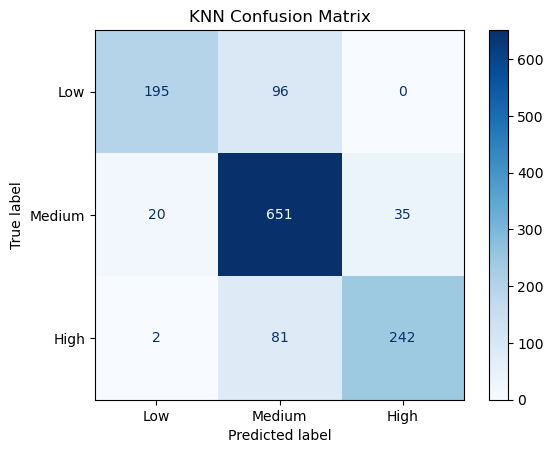

In [7]:
ConfusionMatrixDisplay(
    confusion_matrix=knn_confusion_matrix,
    display_labels=class_order
).plot(cmap="Blues", values_format="d")

plt.title("KNN Confusion Matrix")
plt.grid(False)
plt.show()

## 6. Result interpretation

The optimized KNN model achieved **82.30% test accuracy**, exceeding the majority-class baseline of **53.40%**. Its test Macro F1 was **80.68%**, while the cross-validation accuracy and Macro F1 were **82.27%** and **80.76%**, respectively. The similar cross-validation and test results indicate consistent performance on unseen data.

The Medium class had the strongest recall at **92.21%**, while the Low class had the weakest recall at **67.01%**. The most common errors were 96 Low students and 81 High students being predicted as Medium. Feature selection improved the model by removing weaker transformed features from the KNN distance calculation.